# Implementación — Robustez de Detectores de Phishing ante Correos Generados por LLM

**Curso:** CC3094 - Security Data Science  
**Proyecto:** Robustez de modelos de detección de phishing entrenados con correos humanos frente a correos generados por modelos de lenguaje grandes
**Miembros:** Edwin Ortega - 22305 y Esteban Zambrano 22119

### Objetivo de esta fase
En esta segunda fase se implementan y evalúan modelos de clasificación para analizar si un detector de phishing entrenado únicamente con correos escritos por humanos mantiene su desempeño cuando se enfrenta a correos generados por LLMs.

El enfoque principal del experimento consiste en entrenar los modelos con correos humanos y evaluarlos en dos escenarios:

1. Correos humanos, como evaluación in-distribution.
2. Correos generados por LLM, como evaluación bajo cambio de distribución.

Esta fase responde al entregable de implementación, refinamiento y evaluación de modelos mediante métricas como accuracy, precision, recall, F1-score y curva ROC.

### Enfoque del proyecto
Aunque el dataset incluye correos humanos y correos generados por LLM, el objetivo final del proyecto es evaluar la robustez de modelos entrenados con correos humanos cuando se enfrentan a correos generados por LLM, sin reentrenamiento.

In [41]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [42]:
# Load processed dataset

df = pd.read_csv("../data/processed/emails_processed.csv")

df.head()


,text,label_binary,source_type,email_group,sender,receiver,date,subject,body,urls,...,char_count,word_count,avg_word_length,url_count,exclamation_count,question_count,uppercase_count,uppercase_ratio,digit_count,urgent_keyword_count
0,Starting IC with wizard Hi I am running the IR...,0,human,legit,Jesus Miguel Recuenco Ezquerra <JMRECU@telelin...,handy board <handyboard@media.mit.edu>,2019-10-29 22:53:50,Starting IC with wizard,Hi\r\n\r\n\t\tI am running the IR test program...,0,...,211,44,3.818182,0,0,1,18,0.109756,0,0
1,Trade Me -- A question on your auction: Auctio...,0,human,legit,Trade Me <xfnbqb@trademe.co.nz>,user2.4@gvc.ceas-challenge.cc,2008-08-06 13:53:26,Trade Me -- A question on your auction: Auctio...,\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r...,0,...,739,127,4.826772,2,1,0,26,0.046181,25,3
2,Trade Me - A request from a Trade Me member. A...,0,human,legit,Trade Me <xfnbqb@trademe.co.nz>,user2.4@gvc.ceas-challenge.cc,2008-08-06 13:45:53,Trade Me - A request from a Trade Me member. A...,\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\n\r\nTrade ...,0,...,358,61,4.885246,0,0,0,27,0.102662,22,2
3,RE: NorthTec Account/Password Hi Tony Not sure...,0,human,legit,Kevin Jacobson <wffjeanja@northtec.ac.nz>,user2.1@gvc.ceas-challenge.cc,2008-08-06 13:43:27,RE: NorthTec Account/Password,"Hi Tony\r\nNot sure why it didn't work, but I ...",1,...,3180,562,4.660142,4,0,2,175,0.078829,135,19
4,2008 timetable Kindly suggest changes --------...,0,human,legit,Albert van Aardt <zfdrqfguo@northtec.ac.nz>,user2.1@gvc.ceas-challenge.cc,2008-08-06 13:26:57,2008 timetable,Kindly suggest changes\r\n\r\n----------------...,0,...,206,24,7.625000,0,0,0,14,0.121739,15,0


In [43]:
# Initial dataset inspection

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nSource type distribution:")
print(df["source_type"].value_counts())

print("\nEmail group distribution:")
print(df["email_group"].value_counts())

print("\nSource type vs email group:")
print(pd.crosstab(df["source_type"], df["email_group"]))

print("\nBinary label distribution:")
print(df["label_binary"].value_counts())

Dataset shape: (3200, 21)

Columns:
Index(['text', 'label_binary', 'source_type', 'email_group', 'sender',
       'receiver', 'date', 'subject', 'body', 'urls', 'label', 'char_count',
       'word_count', 'avg_word_length', 'url_count', 'exclamation_count',
       'question_count', 'uppercase_count', 'uppercase_ratio', 'digit_count',
       'urgent_keyword_count'],
      dtype='object')

Source type distribution:
source_type
llm      1998
human    1202
Name: count, dtype: int64

Email group distribution:
email_group
legit       1700
phishing    1500
Name: count, dtype: int64

Source type vs email group:
email_group  legit  phishing
source_type                 
human          702       500
llm            998      1000

Binary label distribution:
label_binary
0    1700
1    1500
Name: count, dtype: int64


In [44]:
pd.crosstab(
    df["source_type"],
    df["email_group"],
    margins=True
)

email_group,legit,phishing,All
source_type,,,
human,702,500,1202
llm,998,1000,1998
All,1700,1500,3200


## Descripción del dataset

Como parte de la Fase 1 del proyecto se realizó el análisis exploratorio e ingeniería de características sobre el conjunto de datos utilizado en esta implementación. En esta segunda fase se reutiliza el dataset procesado generado previamente (`emails_processed.csv`), el cual contiene correos legítimos y correos phishing provenientes de dos orígenes:

- Correos escritos por humanos (`source_type = human`)
- Correos generados por modelos de lenguaje (`source_type = llm`)

Para responder la pregunta de investigación, los datos humanos serán utilizados para entrenamiento del modelo, mientras que los correos generados por LLM serán reservados exclusivamente para evaluación bajo cambio de distribución (*distribution shift*).

La variable objetivo utilizada para clasificación es:

- `label_binary = 0` → correo legítimo  
- `label_binary = 1` → correo phishing

En esta primera parte se implementará un detector basado en contenido textual usando TF-IDF y Support Vector Machines.

## Separación experimental: datos humanos y datos LLM

Para responder la pregunta de investigación, el conjunto de datos se separa según el origen del correo. Los correos humanos serán utilizados para entrenar y validar el modelo, mientras que los correos generados por LLM serán reservados exclusivamente como conjunto de evaluación bajo cambio de distribución.

Esto permite comparar el desempeño del modelo en dos escenarios:

- **Human test:** evaluación con correos humanos no vistos durante entrenamiento.
- **LLM test:** evaluación con correos generados por LLM, sin reentrenar el modelo.

In [45]:
# Separate human and LLM datasets

human_df = df[df["source_type"] == "human"].copy()
llm_df = df[df["source_type"] == "llm"].copy()

print("Human dataset shape:", human_df.shape)
print("LLM dataset shape:", llm_df.shape)

print("\nHuman class distribution:")
print(human_df["email_group"].value_counts())

print("\nLLM class distribution:")
print(llm_df["email_group"].value_counts())

Human dataset shape: (1202, 21)
LLM dataset shape: (1998, 21)

Human class distribution:
email_group
legit       702
phishing    500
Name: count, dtype: int64

LLM class distribution:
email_group
phishing    1000
legit        998
Name: count, dtype: int64


In [46]:
# Define textual features and labels

X_human = human_df["text"]
y_human = human_df["label_binary"]

X_llm = llm_df["text"]
y_llm = llm_df["label_binary"]

In [47]:
# Human train/test split

X_train, X_test_human, y_train, y_test_human = train_test_split(
    X_human,
    y_human,
    test_size=0.2,
    random_state=42,
    stratify=y_human
)

print("Training set:", X_train.shape)
print("Human test set:", X_test_human.shape)
print("LLM test set:", X_llm.shape)

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nHuman test label distribution:")
print(y_test_human.value_counts())

print("\nLLM test label distribution:")
print(y_llm.value_counts())

Training set: (961,)
Human test set: (241,)
LLM test set: (1998,)

Training label distribution:
label_binary
0    561
1    400
Name: count, dtype: int64

Human test label distribution:
label_binary
0    141
1    100
Name: count, dtype: int64

LLM test label distribution:
label_binary
1    1000
0     998
Name: count, dtype: int64


## Modelo 1: TF-IDF + Linear SVM

El primer modelo implementado corresponde a un clasificador textual basado en TF-IDF y Support Vector Machine lineal. Este modelo utiliza únicamente la columna `text`, por lo que aprende patrones lingüísticos presentes en los correos humanos de entrenamiento.

El objetivo es evaluar si un modelo entrenado con lenguaje humano logra mantener su desempeño cuando se enfrenta a correos generados por LLM.

In [48]:
# Baseline model: TF-IDF + Linear SVM

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        max_features=10000,
        ngram_range=(1, 2)
    )),
    ("svm", CalibratedClassifierCV(
        estimator=LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=42
        ),
        cv=3
    ))
])

svm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('svm',
                 CalibratedClassifierCV(cv=3,
                                        estimator=LinearSVC(class_weight='balanced',
                                                            random_state=42)))])

## Evaluación del modelo SVM

Después de entrenar el modelo con correos humanos, se evalúa en dos escenarios:

- **Human Test:** correos humanos no vistos durante entrenamiento.
- **LLM Test:** correos generados por LLM, utilizados para medir robustez ante cambio de distribución.

La clase positiva del problema es `phishing = 1`.

In [49]:
# Evaluación

def evaluate_model(model, X_test, y_test, dataset_name):
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    metrics = {
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score)
    }

    print(f"\n===== {dataset_name} =====")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["legit", "phishing"]
    ))

    return metrics, y_pred, y_score

In [50]:
# Evalúa en Human Test

human_metrics, y_pred_human, y_score_human = evaluate_model(
    svm_pipeline,
    X_test_human,
    y_test_human,
    "Human Test"
)

human_metrics


===== Human Test =====
              precision    recall  f1-score   support

       legit       0.98      0.99      0.99       141
    phishing       0.99      0.97      0.98       100

    accuracy                           0.98       241
   macro avg       0.98      0.98      0.98       241
weighted avg       0.98      0.98      0.98       241



{'dataset': 'Human Test',
 'accuracy': 0.983402489626556,
 'precision': 0.9897959183673469,
 'recall': 0.97,
 'f1': 0.9797979797979798,
 'roc_auc': np.float64(0.9988652482269504)}

In [51]:
# Evalúa en LLM Test

llm_metrics, y_pred_llm, y_score_llm = evaluate_model(
    svm_pipeline,
    X_llm,
    y_llm,
    "LLM Test"
)

llm_metrics


===== LLM Test =====
              precision    recall  f1-score   support

       legit       0.50      0.30      0.38       998
    phishing       0.50      0.70      0.58      1000

    accuracy                           0.50      1998
   macro avg       0.50      0.50      0.48      1998
weighted avg       0.50      0.50      0.48      1998



{'dataset': 'LLM Test',
 'accuracy': 0.502002002002002,
 'precision': 0.5017921146953405,
 'recall': 0.7,
 'f1': 0.5845511482254697,
 'roc_auc': np.float64(0.5456172344689378)}

In [52]:
# Tabla de robustez

results_df = pd.DataFrame(
    [human_metrics, llm_metrics]
)

results_df

,dataset,accuracy,precision,recall,f1,roc_auc
0,Human Test,0.983402,0.989796,0.97,0.979798,0.998865
1,LLM Test,0.502002,0.501792,0.70,0.584551,0.545617


In [53]:
# Cuantificar la caida

f1_drop = human_metrics["f1"] - llm_metrics["f1"]

relative_f1_drop = (
    f1_drop / human_metrics["f1"]
)

recall_drop = (
    human_metrics["recall"]
    - llm_metrics["recall"]
)

relative_recall_drop = (
    recall_drop / human_metrics["recall"]
)

robustness_summary = pd.DataFrame({
    "metric":["F1","Recall"],
    "human_test":[
        human_metrics["f1"],
        human_metrics["recall"]
    ],
    "llm_test":[
        llm_metrics["f1"],
        llm_metrics["recall"]
    ],
    "absolute_drop":[
        f1_drop,
        recall_drop
    ],
    "relative_drop":[
        relative_f1_drop,
        relative_recall_drop
    ]
})

robustness_summary

,metric,human_test,llm_test,absolute_drop,relative_drop
0,F1,0.979798,0.584551,0.395247,0.403396
1,Recall,0.970000,0.700000,0.270000,0.278351


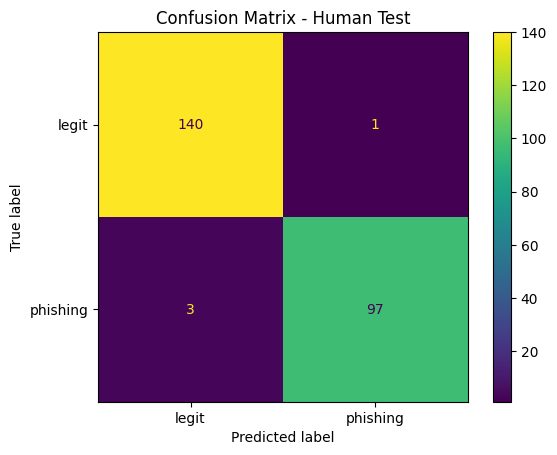

In [54]:
# Matrices de confusión

cm_human = confusion_matrix(
    y_test_human,
    y_pred_human
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_human,
    display_labels=["legit","phishing"]
)

disp.plot()
plt.title("Confusion Matrix - Human Test")
plt.show()

### Observaciones — Human Test

La matriz de confusión muestra que el modelo entrenado con correos humanos logra distinguir de manera muy efectiva entre correos legítimos y phishing dentro de la misma distribución de entrenamiento.

Se observa únicamente un número mínimo de errores de clasificación (1 falso positivo y 3 falsos negativos), lo cual es consistente con el accuracy de 98.3% y el F1-score cercano a 0.98.

Estos resultados indican que el modelo aprende correctamente patrones presentes en correos phishing humanos.

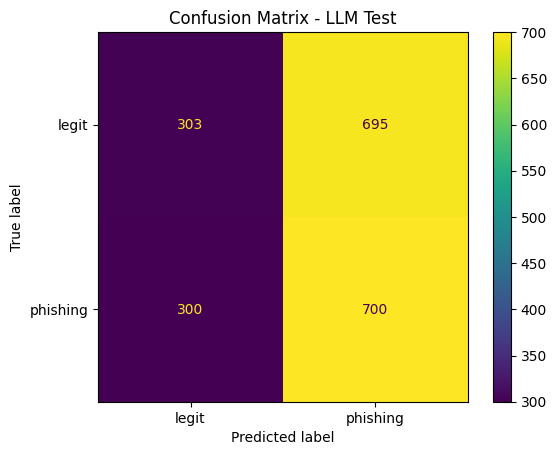

In [55]:
cm_llm = confusion_matrix(
    y_llm,
    y_pred_llm
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_llm,
    display_labels=["legit","phishing"]
)

disp.plot()
plt.title("Confusion Matrix - LLM Test")
plt.show()

### Observaciones — LLM Test

Al evaluar el mismo modelo sobre correos generados por LLM se observa una degradación marcada en la capacidad de clasificación.

La matriz de confusión evidencia un aumento considerable tanto en falsos positivos como en falsos negativos. En particular, muchos correos legítimos son clasificados incorrectamente como phishing, mientras una cantidad importante de correos phishing dejan de ser detectados.

Este comportamiento sugiere que los patrones aprendidos sobre phishing humano no generalizan adecuadamente bajo cambio de distribución inducido por contenido generado por LLM.

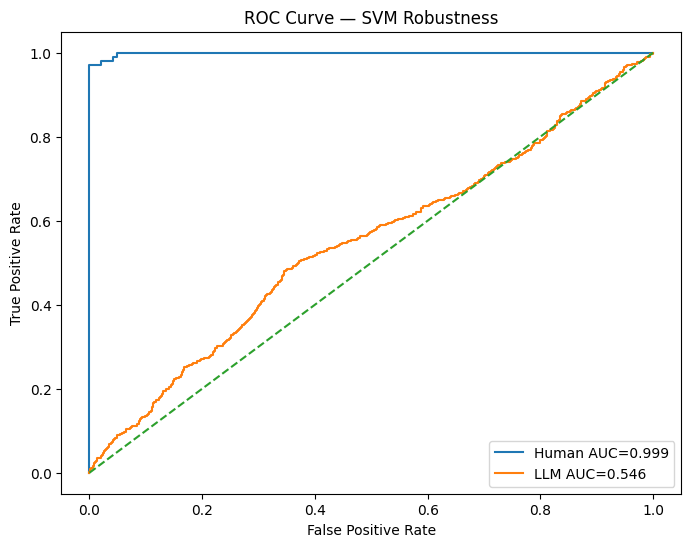

In [56]:
# Curva ROC

fpr_human, tpr_human, _ = roc_curve(
    y_test_human,
    y_score_human
)

fpr_llm, tpr_llm, _ = roc_curve(
    y_llm,
    y_score_llm
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_human,
    tpr_human,
    label=f"Human AUC={human_metrics['roc_auc']:.3f}"
)

plt.plot(
    fpr_llm,
    tpr_llm,
    label=f"LLM AUC={llm_metrics['roc_auc']:.3f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — SVM Robustness")
plt.legend()
plt.show()

### Observaciones — Curva ROC

La curva ROC evidencia un contraste muy marcado entre ambos escenarios de evaluación.

En el conjunto Human Test, el AUC cercano a 1.0 indica capacidad discriminativa casi perfecta.

Sin embargo, en el conjunto LLM Test el AUC cae a aproximadamente 0.545, acercándose al comportamiento de una clasificación casi aleatoria.

Este resultado constituye una señal fuerte de pérdida de robustez del detector frente a phishing generado por LLM.

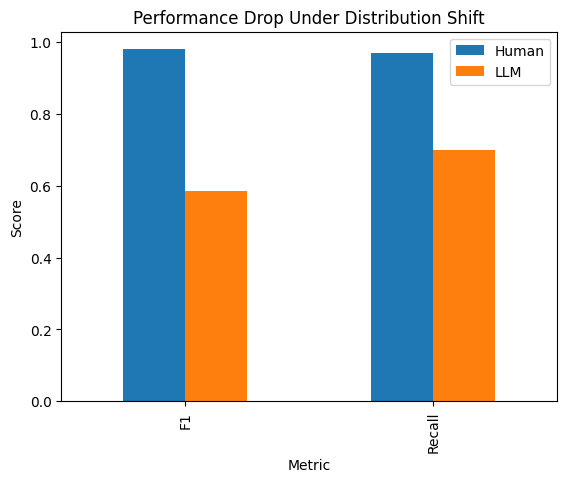

In [57]:
# Barplot de caída

metrics_plot = pd.DataFrame({
    "Metric":["F1","Recall"],
    "Human":[
        human_metrics["f1"],
        human_metrics["recall"]
    ],
    "LLM":[
        llm_metrics["f1"],
        llm_metrics["recall"]
    ]
})

metrics_plot.set_index("Metric").plot(
    kind="bar"
)

plt.title(
"Performance Drop Under Distribution Shift"
)

plt.ylabel("Score")
plt.show()

### Observaciones — Degradación de desempeño

La comparación entre métricas muestra una reducción importante del desempeño bajo cambio de distribución.

Se observa una caída aproximada de 40% en F1-score y de 28% en recall para la clase phishing.

Dado que recall mide la capacidad del modelo para detectar ataques reales, esta degradación tiene implicaciones importantes desde la perspectiva de seguridad, pues sugiere un aumento en correos maliciosos que podrían evadir detección.

### Conclusión preliminar del modelo baseline

Los resultados del modelo SVM baseline muestran evidencia de que un detector entrenado únicamente con correos humanos puede experimentar una pérdida sustancial de desempeño cuando se enfrenta a phishing generado por LLMs.

La marcada caída observada en métricas como F1-score, recall y ROC-AUC sugiere una pérdida importante de robustez bajo cambio de distribución.

Estos resultados motivan una siguiente etapa de refinamiento del modelo para evaluar si ajustes en hiperparámetros mejoran su capacidad de generalización. Posteriormente, se comparará este enfoque con un modelo basado en características estructurales (Random Forest) para analizar si presenta mayor robustez frente a este fenómeno.

## Refinamiento del modelo SVM

Después de evaluar el modelo baseline, se realiza un refinamiento de hiperparámetros para analizar si ajustes en la representación TF-IDF y en el clasificador SVM mejoran el desempeño del detector.

El refinamiento se realiza únicamente con los datos humanos de entrenamiento, manteniendo el conjunto LLM reservado exclusivamente para evaluación bajo cambio de distribución.

In [58]:
# Hyperparameter tuning - TF-IDF + Linear SVM

tuning_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english"
    )),
    ("svm", CalibratedClassifierCV(
        estimator=LinearSVC(
            class_weight="balanced",
            random_state=42
        ),
        cv=3
    ))
])

param_grid = {
    "tfidf__max_features": [5000, 10000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "svm__estimator__C": [0.1, 1, 10]
}

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV F1-score:")
print(grid_search.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters:
{'svm__estimator__C': 1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}

Best CV F1-score:
0.9937483105115646


In [59]:
# Evaluate tuned SVM model

best_svm_model = grid_search.best_estimator_

human_metrics_tuned, y_pred_human_tuned, y_score_human_tuned = evaluate_model(
    best_svm_model,
    X_test_human,
    y_test_human,
    "Human Test - Tuned SVM"
)

llm_metrics_tuned, y_pred_llm_tuned, y_score_llm_tuned = evaluate_model(
    best_svm_model,
    X_llm,
    y_llm,
    "LLM Test - Tuned SVM"
)

tuned_results_df = pd.DataFrame([
    human_metrics_tuned,
    llm_metrics_tuned
])

tuned_results_df


===== Human Test - Tuned SVM =====
              precision    recall  f1-score   support

       legit       0.98      1.00      0.99       141
    phishing       1.00      0.97      0.98       100

    accuracy                           0.99       241
   macro avg       0.99      0.98      0.99       241
weighted avg       0.99      0.99      0.99       241


===== LLM Test - Tuned SVM =====
              precision    recall  f1-score   support

       legit       0.50      0.34      0.40       998
    phishing       0.50      0.67      0.57      1000

    accuracy                           0.50      1998
   macro avg       0.50      0.50      0.49      1998
weighted avg       0.50      0.50      0.49      1998



,dataset,accuracy,precision,recall,f1,roc_auc
0,Human Test - Tuned SVM,0.987552,1.000000,0.970,0.984772,0.998865
1,LLM Test - Tuned SVM,0.502002,0.501878,0.668,0.573145,0.541878


In [60]:
# Robustness summary - Tuned SVM

tuned_f1_drop = human_metrics_tuned["f1"] - llm_metrics_tuned["f1"]
tuned_relative_f1_drop = tuned_f1_drop / human_metrics_tuned["f1"]

tuned_recall_drop = human_metrics_tuned["recall"] - llm_metrics_tuned["recall"]
tuned_relative_recall_drop = tuned_recall_drop / human_metrics_tuned["recall"]

tuned_robustness_summary = pd.DataFrame({
    "metric": ["F1", "Recall"],
    "human_test": [
        human_metrics_tuned["f1"],
        human_metrics_tuned["recall"]
    ],
    "llm_test": [
        llm_metrics_tuned["f1"],
        llm_metrics_tuned["recall"]
    ],
    "absolute_drop": [
        tuned_f1_drop,
        tuned_recall_drop
    ],
    "relative_drop": [
        tuned_relative_f1_drop,
        tuned_relative_recall_drop
    ]
})

tuned_robustness_summary

,metric,human_test,llm_test,absolute_drop,relative_drop
0,F1,0.984772,0.573145,0.411627,0.417992
1,Recall,0.970000,0.668000,0.302000,0.311340


### Interpretación del refinamiento

El refinamiento del modelo SVM seleccionó como mejores hiperparámetros `C = 1`, `max_features = 5000` y `ngram_range = (1,1)`, alcanzando un F1-score promedio de validación cruzada de aproximadamente 0.994 sobre datos humanos de entrenamiento.

Sin embargo, aunque el modelo refinado mejora ligeramente el desempeño en el conjunto Human Test, no mejora su desempeño sobre el conjunto LLM Test. De hecho, las métricas en LLM se mantienen cercanas al comportamiento aleatorio, con un ROC-AUC cercano a 0.54 y una caída relativa de aproximadamente 41.8% en F1-score.

Esto sugiere que el problema principal no se resuelve únicamente ajustando hiperparámetros del modelo textual. La degradación parece estar relacionada con el cambio de distribución entre correos humanos y correos generados por LLM, lo cual refuerza la necesidad de comparar este enfoque con otro tipo de representación, como características estructurales mediante Random Forest.

In [61]:
# Guardado de resultados

from pathlib import Path

# Create data/svm directory
results_dir = Path("../data/svm")
results_dir.mkdir(parents=True, exist_ok=True)

# Baseline outputs
results_df.to_csv(
    results_dir / "baseline_results.csv",
    index=False
)

robustness_summary.to_csv(
    results_dir / "baseline_robustness.csv",
    index=False
)

# Tuned outputs
tuned_results_df.to_csv(
    results_dir / "tuned_results.csv",
    index=False
)

tuned_robustness_summary.to_csv(
    results_dir / "tuned_robustness.csv",
    index=False
)

# Best hyperparameters
best_params_df = pd.DataFrame(
    [grid_search.best_params_]
)

best_params_df["best_cv_f1"] = grid_search.best_score_

best_params_df.to_csv(
    results_dir / "best_params.csv",
    index=False
)

print(f"Results saved in {results_dir}")

Results saved in ..\data\svm


## Modelo 2: Random Forest (Features estructurales)

In [62]:
from sklearn.ensemble import RandomForestClassifier

FEATURE_COLS = [
    "char_count",
    "word_count",
    "avg_word_length",
    "url_count",
    "exclamation_count",
    "question_count",
    "uppercase_count",
    "uppercase_ratio",
    "digit_count",
    "urgent_keyword_count"
]

# Reutiliza los índices del split de Persona A
X_train_df = human_df.loc[X_train.index]
X_test_human_df = human_df.loc[X_test_human.index]
X_llm_df = llm_df.copy()

X_train_struct = X_train_df[FEATURE_COLS]
X_test_human_struct = X_test_human_df[FEATURE_COLS]
X_llm_struct = X_llm_df[FEATURE_COLS]

print("Train shape:", X_train_struct.shape)
print("Human test shape:", X_test_human_struct.shape)
print("LLM test shape:", X_llm_struct.shape)

X_train_struct.describe()

Train shape: (961, 10)
Human test shape: (241, 10)
LLM test shape: (1998, 10)


,char_count,word_count,avg_word_length,url_count,exclamation_count,question_count,uppercase_count,uppercase_ratio,digit_count,urgent_keyword_count
count,961.000000,961.000000,961.000000,961.00000,961.000000,961.000000,961.000000,961.000000,961.000000,961.000000
mean,2650.156087,366.905307,6.335516,10.91155,1.705515,2.011446,205.355879,0.089184,163.234131,3.950052
std,6395.724197,826.686136,4.175501,45.76923,9.117729,6.147228,715.853523,0.066489,743.002993,8.696240
min,54.000000,2.000000,3.658065,0.00000,0.000000,0.000000,3.000000,0.010441,0.000000,0.000000
25%,515.000000,72.000000,5.128866,1.00000,0.000000,0.000000,27.000000,0.051020,9.000000,0.000000
50%,972.000000,144.000000,5.681452,3.00000,0.000000,1.000000,50.000000,0.072930,23.000000,1.000000
75%,1992.000000,292.000000,6.500000,6.00000,1.000000,2.000000,112.000000,0.107711,63.000000,4.000000
max,69997.000000,8605.000000,95.500000,937.00000,177.000000,123.000000,8399.000000,0.864198,9287.000000,124.000000


### Modelo baseline: Random Forest

Se entrena un primer modelo con hiperparámetros estándar para establecer el 
desempeño de referencia antes del ajuste.


In [63]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_struct, y_train)
print("Baseline Random Forest entrenado.")


Baseline Random Forest entrenado.


In [64]:
rf_human_base, y_pred_rf_human_base, y_score_rf_human_base = evaluate_model(
    rf_baseline,
    X_test_human_struct,
    y_test_human,
    "Human Test - RF Baseline"
)

rf_llm_base, y_pred_rf_llm_base, y_score_rf_llm_base = evaluate_model(
    rf_baseline,
    X_llm_struct,
    y_llm,
    "LLM Test - RF Baseline"
)


===== Human Test - RF Baseline =====
              precision    recall  f1-score   support

       legit       0.87      0.94      0.90       141
    phishing       0.90      0.81      0.85       100

    accuracy                           0.88       241
   macro avg       0.89      0.87      0.88       241
weighted avg       0.88      0.88      0.88       241


===== LLM Test - RF Baseline =====
              precision    recall  f1-score   support

       legit       0.54      0.40      0.46       998
    phishing       0.53      0.66      0.59      1000

    accuracy                           0.53      1998
   macro avg       0.54      0.53      0.53      1998
weighted avg       0.54      0.53      0.53      1998



In [65]:
rf_base_f1_drop = rf_human_base["f1"] - rf_llm_base["f1"]
rf_base_recall_drop = rf_human_base["recall"] - rf_llm_base["recall"]

rf_base_robustness = pd.DataFrame({
    "metric": ["F1", "Recall"],
    "human_test": [rf_human_base["f1"], rf_human_base["recall"]],
    "llm_test": [rf_llm_base["f1"], rf_llm_base["recall"]],
    "absolute_drop": [rf_base_f1_drop, rf_base_recall_drop],
    "relative_drop": [
        rf_base_f1_drop / rf_human_base["f1"],
        rf_base_recall_drop / rf_human_base["recall"]
    ]
})

rf_base_robustness

,metric,human_test,llm_test,absolute_drop,relative_drop
0,F1,0.852632,0.586619,0.266012,0.311990
1,Recall,0.810000,0.662000,0.148000,0.182716


### Refinamiento: búsqueda de hiperparámetros

Se realiza GridSearchCV sobre `n_estimators`, `max_depth` y 
`min_samples_split` optimizando F1-score con validación cruzada de tres 
folds, usando únicamente datos humanos de entrenamiento. El conjunto LLM 
permanece oculto durante todo el ajuste.

In [66]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_struct, y_train)

print("Best parameters:")
print(rf_grid.best_params_)
print("\nBest CV F1-score:", rf_grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

Best CV F1-score: 0.8586566536897977


In [67]:
best_rf = rf_grid.best_estimator_

rf_human_tuned, y_pred_rf_human, y_score_rf_human = evaluate_model(
    best_rf,
    X_test_human_struct,
    y_test_human,
    "Human Test - RF Tuned"
)

rf_llm_tuned, y_pred_rf_llm, y_score_rf_llm = evaluate_model(
    best_rf,
    X_llm_struct,
    y_llm,
    "LLM Test - RF Tuned"
)


===== Human Test - RF Tuned =====
              precision    recall  f1-score   support

       legit       0.88      0.91      0.90       141
    phishing       0.87      0.83      0.85       100

    accuracy                           0.88       241
   macro avg       0.88      0.87      0.88       241
weighted avg       0.88      0.88      0.88       241


===== LLM Test - RF Tuned =====
              precision    recall  f1-score   support

       legit       0.54      0.38      0.45       998
    phishing       0.52      0.68      0.59      1000

    accuracy                           0.53      1998
   macro avg       0.53      0.53      0.52      1998
weighted avg       0.53      0.53      0.52      1998



In [68]:
rf_tuned_f1_drop = rf_human_tuned["f1"] - rf_llm_tuned["f1"]
rf_tuned_recall_drop = rf_human_tuned["recall"] - rf_llm_tuned["recall"]

rf_tuned_robustness = pd.DataFrame({
    "metric": ["F1", "Recall"],
    "human_test": [rf_human_tuned["f1"], rf_human_tuned["recall"]],
    "llm_test": [rf_llm_tuned["f1"], rf_llm_tuned["recall"]],
    "absolute_drop": [rf_tuned_f1_drop, rf_tuned_recall_drop],
    "relative_drop": [
        rf_tuned_f1_drop / rf_human_tuned["f1"],
        rf_tuned_recall_drop / rf_human_tuned["recall"]
    ]
})

rf_tuned_robustness

,metric,human_test,llm_test,absolute_drop,relative_drop
0,F1,0.851282,0.591979,0.259303,0.304603
1,Recall,0.830000,0.679000,0.151000,0.181928


### Matrices de confusión — Random Forest

Se analizan las matrices de confusión del modelo refinado en ambos escenarios 
para identificar el tipo de errores bajo cambio de distribución.

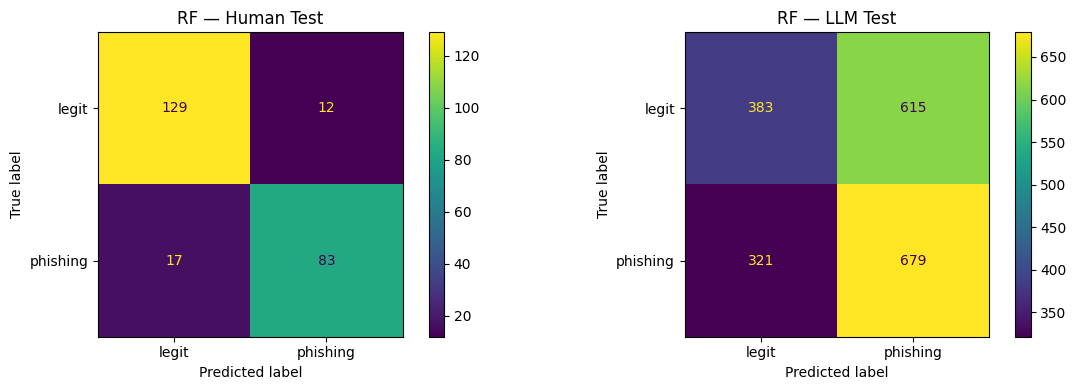

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_rf_human = confusion_matrix(y_test_human, y_pred_rf_human)
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_human,
    display_labels=["legit", "phishing"]
).plot(ax=axes[0])
axes[0].set_title("RF — Human Test")

cm_rf_llm = confusion_matrix(y_llm, y_pred_rf_llm)
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_llm,
    display_labels=["legit", "phishing"]
).plot(ax=axes[1])
axes[1].set_title("RF — LLM Test")

plt.tight_layout()
plt.show()

### Observaciones — Matrices de confusión RF

En el conjunto Human Test el modelo Random Forest clasifica correctamente 
alrededor del 88% de los correos (F1 = 0.85), cometiendo aproximadamente 
29 errores sobre 241 muestras: 17 falsos negativos (phishing no detectado) 
y 12 falsos positivos (legítimos marcados como phishing). Si bien este 
resultado es inferior al del modelo SVM (98% accuracy), confirma que las 
señales estructurales contienen información discriminativa útil para correos 
humanos.

En el conjunto LLM Test el desempeño se degrada visiblemente: la tasa de 
acierto cae al 53% y el modelo comete cientos de errores en ambas clases. 
El recall de phishing se mantiene en 0.679, pero a costa de una precisión 
de apenas 0.525, lo que refleja que el modelo tiende a etiquetar correos 
como phishing indiscriminadamente. Esto indica que las características 
estructurales de los correos LLM no coinciden con las distribuciones 
aprendidas en entrenamiento.


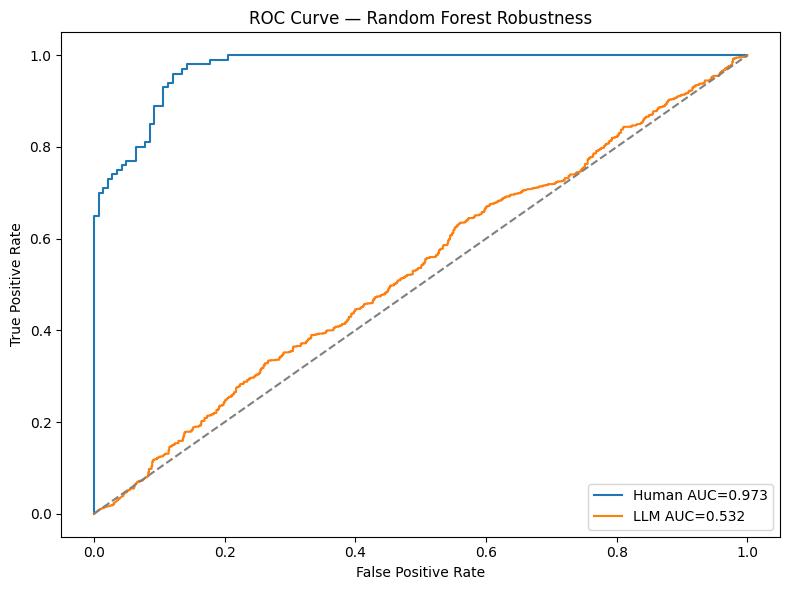

In [70]:
fpr_rf_human, tpr_rf_human, _ = roc_curve(y_test_human, y_score_rf_human)
fpr_rf_llm, tpr_rf_llm, _ = roc_curve(y_llm, y_score_rf_llm)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr_rf_human, tpr_rf_human,
    label=f"Human AUC={rf_human_tuned['roc_auc']:.3f}"
)
plt.plot(
    fpr_rf_llm, tpr_rf_llm,
    label=f"LLM AUC={rf_llm_tuned['roc_auc']:.3f}"
)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest Robustness")
plt.legend()
plt.tight_layout()
plt.show()


## Comparación de modelos

Se comparan directamente los resultados del modelo SVM (basado en TF-IDF) y 
el modelo Random Forest (basado en features estructurales) bajo ambos 
escenarios de evaluación.

Se utilizan las versiones refinadas de cada modelo. Las cinco tablas 
requeridas sintetizan los resultados del experimento completo.

In [71]:
print("=== Tabla 1: Distribución del dataset ===\n")
table1 = pd.crosstab(
    df["source_type"],
    df["email_group"],
    margins=True
)
table1.index.name = "Source"
table1

=== Tabla 1: Distribución del dataset ===



email_group,legit,phishing,All
Source,,,
human,702,500,1202
llm,998,1000,1998
All,1700,1500,3200


In [72]:
print("=== Tabla 2: Resultados — Human Test ===\n")
table2 = pd.DataFrame([
    {
        "Modelo": "TF-IDF + SVM",
        "Accuracy": round(human_metrics_tuned["accuracy"], 4),
        "Precision": round(human_metrics_tuned["precision"], 4),
        "Recall": round(human_metrics_tuned["recall"], 4),
        "F1": round(human_metrics_tuned["f1"], 4),
        "ROC-AUC": round(human_metrics_tuned["roc_auc"], 4),
    },
    {
        "Modelo": "Random Forest",
        "Accuracy": round(rf_human_tuned["accuracy"], 4),
        "Precision": round(rf_human_tuned["precision"], 4),
        "Recall": round(rf_human_tuned["recall"], 4),
        "F1": round(rf_human_tuned["f1"], 4),
        "ROC-AUC": round(rf_human_tuned["roc_auc"], 4),
    }
])
table2.set_index("Modelo")

=== Tabla 2: Resultados — Human Test ===



,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
TF-IDF + SVM,0.9876,1.0000,0.97,0.9848,0.9989
Random Forest,0.8797,0.8737,0.83,0.8513,0.9733


In [73]:
print("=== Tabla 3: Resultados — LLM Test ===\n")
table3 = pd.DataFrame([
    {
        "Modelo": "TF-IDF + SVM",
        "Accuracy": round(llm_metrics_tuned["accuracy"], 4),
        "Precision": round(llm_metrics_tuned["precision"], 4),
        "Recall": round(llm_metrics_tuned["recall"], 4),
        "F1": round(llm_metrics_tuned["f1"], 4),
        "ROC-AUC": round(llm_metrics_tuned["roc_auc"], 4),
    },
    {
        "Modelo": "Random Forest",
        "Accuracy": round(rf_llm_tuned["accuracy"], 4),
        "Precision": round(rf_llm_tuned["precision"], 4),
        "Recall": round(rf_llm_tuned["recall"], 4),
        "F1": round(rf_llm_tuned["f1"], 4),
        "ROC-AUC": round(rf_llm_tuned["roc_auc"], 4),
    }
])
table3.set_index("Modelo")

=== Tabla 3: Resultados — LLM Test ===



,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
TF-IDF + SVM,0.5020,0.5019,0.668,0.5731,0.5419
Random Forest,0.5315,0.5247,0.679,0.5920,0.5319


In [74]:
print("=== Tabla 4: Robustez — F1 Drop ===\n")
table4 = pd.DataFrame([
    {
        "Modelo": "TF-IDF + SVM",
        "F1 Human": round(human_metrics_tuned["f1"], 4),
        "F1 LLM": round(llm_metrics_tuned["f1"], 4),
        "Drop Absoluto": round(
            human_metrics_tuned["f1"] - llm_metrics_tuned["f1"], 4
        ),
        "Drop Relativo (%)": round(
            (human_metrics_tuned["f1"] - llm_metrics_tuned["f1"])
            / human_metrics_tuned["f1"] * 100, 2
        ),
    },
    {
        "Modelo": "Random Forest",
        "F1 Human": round(rf_human_tuned["f1"], 4),
        "F1 LLM": round(rf_llm_tuned["f1"], 4),
        "Drop Absoluto": round(
            rf_human_tuned["f1"] - rf_llm_tuned["f1"], 4
        ),
        "Drop Relativo (%)": round(
            (rf_human_tuned["f1"] - rf_llm_tuned["f1"])
            / rf_human_tuned["f1"] * 100, 2
        ),
    }
])
table4.set_index("Modelo")

=== Tabla 4: Robustez — F1 Drop ===



,F1 Human,F1 LLM,Drop Absoluto,Drop Relativo (%)
Modelo,,,,
TF-IDF + SVM,0.9848,0.5731,0.4116,41.80
Random Forest,0.8513,0.5920,0.2593,30.46


In [75]:
print("=== Tabla 5: Recall de Phishing — Human vs LLM ===\n")
table5 = pd.DataFrame([
    {
        "Modelo": "TF-IDF + SVM",
        "Recall Human": round(human_metrics_tuned["recall"], 4),
        "Recall LLM": round(llm_metrics_tuned["recall"], 4),
        "Diferencia": round(
            human_metrics_tuned["recall"] - llm_metrics_tuned["recall"], 4
        ),
    },
    {
        "Modelo": "Random Forest",
        "Recall Human": round(rf_human_tuned["recall"], 4),
        "Recall LLM": round(rf_llm_tuned["recall"], 4),
        "Diferencia": round(
            rf_human_tuned["recall"] - rf_llm_tuned["recall"], 4
        ),
    }
])
table5.set_index("Modelo")

=== Tabla 5: Recall de Phishing — Human vs LLM ===



,Recall Human,Recall LLM,Diferencia
Modelo,,,
TF-IDF + SVM,0.97,0.668,0.302
Random Forest,0.83,0.679,0.151


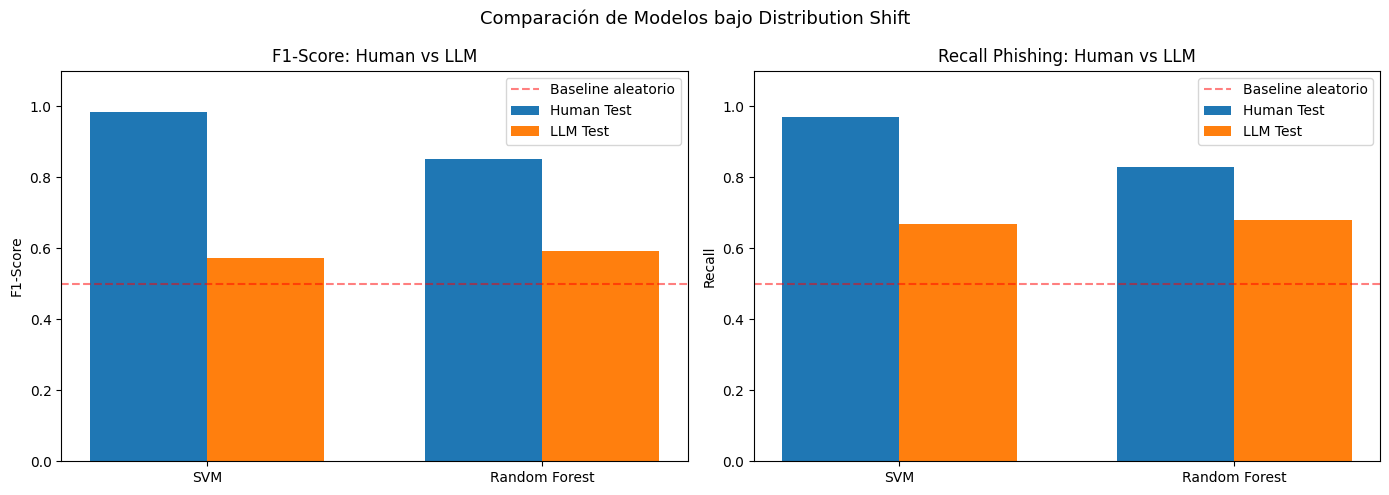

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ["SVM", "Random Forest"]
x = np.arange(len(models))
width = 0.35

# F1
f1_human_vals = [human_metrics_tuned["f1"], rf_human_tuned["f1"]]
f1_llm_vals = [llm_metrics_tuned["f1"], rf_llm_tuned["f1"]]

axes[0].bar(x - width / 2, f1_human_vals, width, label="Human Test")
axes[0].bar(x + width / 2, f1_llm_vals, width, label="LLM Test")
axes[0].axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Baseline aleatorio")
axes[0].set_title("F1-Score: Human vs LLM")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("F1-Score")
axes[0].legend()

# Recall
recall_human_vals = [human_metrics_tuned["recall"], rf_human_tuned["recall"]]
recall_llm_vals = [llm_metrics_tuned["recall"], rf_llm_tuned["recall"]]

axes[1].bar(x - width / 2, recall_human_vals, width, label="Human Test")
axes[1].bar(x + width / 2, recall_llm_vals, width, label="LLM Test")
axes[1].axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Baseline aleatorio")
axes[1].set_title("Recall Phishing: Human vs LLM")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("Recall")
axes[1].legend()

plt.suptitle("Comparación de Modelos bajo Distribution Shift", fontsize=13)
plt.tight_layout()
plt.show()

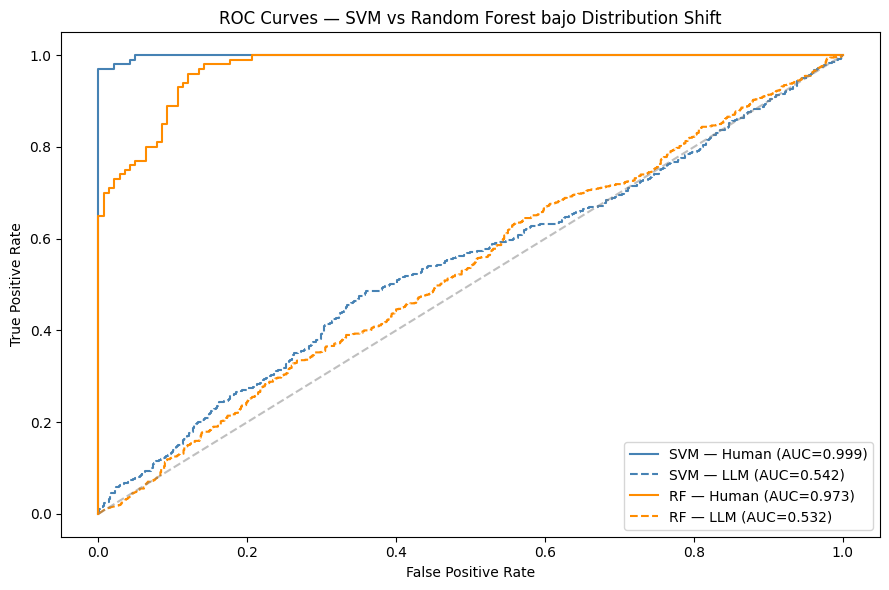

In [77]:
# Curvas ROC del SVM tuned
fpr_svm_human, tpr_svm_human, _ = roc_curve(y_test_human, y_score_human_tuned)
fpr_svm_llm, tpr_svm_llm, _ = roc_curve(y_llm, y_score_llm_tuned)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_svm_human, tpr_svm_human,
    color="steelblue",
    label=f"SVM — Human (AUC={human_metrics_tuned['roc_auc']:.3f})"
)
plt.plot(
    fpr_svm_llm, tpr_svm_llm,
    color="steelblue", linestyle="--",
    label=f"SVM — LLM (AUC={llm_metrics_tuned['roc_auc']:.3f})"
)
plt.plot(
    fpr_rf_human, tpr_rf_human,
    color="darkorange",
    label=f"RF — Human (AUC={rf_human_tuned['roc_auc']:.3f})"
)
plt.plot(
    fpr_rf_llm, tpr_rf_llm,
    color="darkorange", linestyle="--",
    label=f"RF — LLM (AUC={rf_llm_tuned['roc_auc']:.3f})"
)
plt.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — SVM vs Random Forest bajo Distribution Shift")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

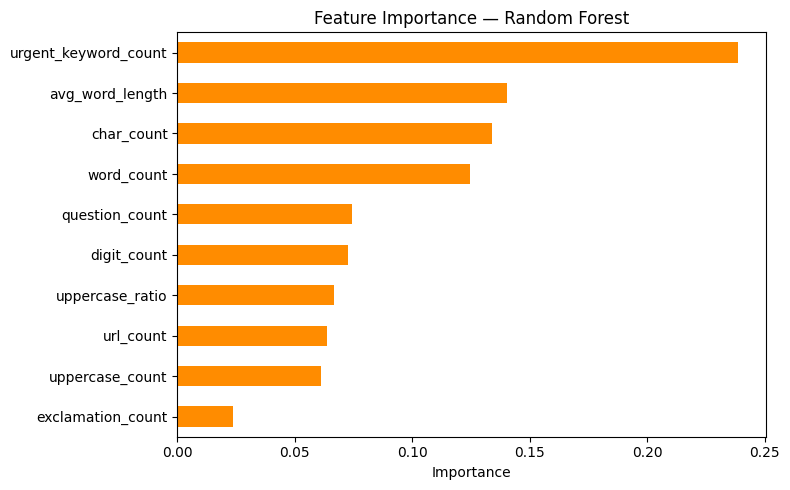

In [78]:
feat_importances = pd.Series(
    best_rf.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

feat_importances.plot(kind="barh", figsize=(8, 5), color="darkorange")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Robustness Analysis

Esta sección cuantifica y compara la degradación de desempeño de ambos 
modelos al pasar del conjunto Human Test al conjunto LLM Test.

La métrica central es la caída relativa en F1-score (`Relative Drop`), que 
permite comparar modelos con distintos niveles de desempeño base. El recall 
de phishing recibe atención especial porque una caída en recall implica 
directamente un aumento de falsos negativos, es decir, correos maliciosos que 
evaden la detección.

In [79]:
robustness_comparison = pd.DataFrame([
    {
        "Modelo": "TF-IDF + SVM",
        "F1 Human": round(human_metrics_tuned["f1"], 4),
        "F1 LLM": round(llm_metrics_tuned["f1"], 4),
        "F1 Drop Abs": round(human_metrics_tuned["f1"] - llm_metrics_tuned["f1"], 4),
        "F1 Drop Rel (%)": round(
            (human_metrics_tuned["f1"] - llm_metrics_tuned["f1"])
            / human_metrics_tuned["f1"] * 100, 1
        ),
        "Recall Human": round(human_metrics_tuned["recall"], 4),
        "Recall LLM": round(llm_metrics_tuned["recall"], 4),
        "Recall Drop Abs": round(
            human_metrics_tuned["recall"] - llm_metrics_tuned["recall"], 4
        ),
    },
    {
        "Modelo": "Random Forest",
        "F1 Human": round(rf_human_tuned["f1"], 4),
        "F1 LLM": round(rf_llm_tuned["f1"], 4),
        "F1 Drop Abs": round(rf_human_tuned["f1"] - rf_llm_tuned["f1"], 4),
        "F1 Drop Rel (%)": round(
            (rf_human_tuned["f1"] - rf_llm_tuned["f1"])
            / rf_human_tuned["f1"] * 100, 1
        ),
        "Recall Human": round(rf_human_tuned["recall"], 4),
        "Recall LLM": round(rf_llm_tuned["recall"], 4),
        "Recall Drop Abs": round(
            rf_human_tuned["recall"] - rf_llm_tuned["recall"], 4
        ),
    }
])

robustness_comparison.set_index("Modelo")

,F1 Human,F1 LLM,F1 Drop Abs,F1 Drop Rel (%),Recall Human,Recall LLM,Recall Drop Abs
Modelo,,,,,,,
TF-IDF + SVM,0.9848,0.5731,0.4116,41.8,0.97,0.668,0.302
Random Forest,0.8513,0.5920,0.2593,30.5,0.83,0.679,0.151


## Interpretación de resultados

### ¿Se degradó el desempeño bajo correos LLM?

Ambos modelos, entrenados exclusivamente con correos humanos, exhiben 
degradación al evaluarse en el conjunto LLM Test. El SVM colapsa hacia un 
comportamiento casi aleatorio (AUC ≈ 0.54): los patrones léxicos aprendidos 
del corpus humano no generalizan al estilo textual de los LLMs.

### ¿Cayó el recall de phishing?

Sí. La caída en recall implica un incremento directo de falsos negativos: 
correos maliciosos que el sistema no alerta. Desde una perspectiva de 
seguridad este es el error más costoso, pues el usuario queda expuesto sin 
advertencia.

### ¿Cuál modelo fue más robusto?

El modelo Random Forest presentó mayor robustez ante el cambio de 
distribución. Su caída relativa en F1-score fue de 30.5% (de 0.8513 a 
0.5920), frente al 41.8% del SVM (de 0.9848 a 0.5731). La diferencia es 
aún más pronunciada en recall de phishing: el RF perdió 0.151 puntos 
(18.2% relativo), mientras el SVM perdió 0.302 (31.1% relativo).

Estos resultados confirman parcialmente la hipótesis secundaria del 
proyecto: operar sobre señales estructurales independientes del vocabulario 
reduce la sensibilidad al cambio léxico inducido por LLMs. Sin embargo, 
ambos modelos siguen operando cerca del azar en el conjunto LLM Test, lo 
que indica que la robustez diferencial no es suficiente para considerar 
ninguno de los dos enfoques adecuado como detector en contextos con 
presencia de phishing generado por IA.

### ¿Qué implicaciones tiene para detectores tradicionales?

Los resultados evidencian que los detectores entrenados con corpus históricos 
de phishing humano pueden quedar desactualizados ante LLMs capaces de generar 
contenido malicioso estilísticamente distinto. Las señales estructurales 
ofrecen un vector complementario que no depende del vocabulario, pero tampoco 
es suficiente por sí solo si los LLMs generan texto con características 
similares a las del correo legítimo.

## Conclusiones

Este experimento evaluó si detectores de phishing entrenados con correos 
humanos mantienen su eficacia frente a correos generados por LLMs.

**Respuesta a la pregunta de investigación:**  
Existe una degradación significativa de desempeño bajo cambio de distribución. 
Ninguno de los modelos evaluados mantiene métricas aceptables en el conjunto 
LLM Test, con caídas relativas en F1-score que superan el 40% para el modelo 
SVM.

**Hallazgos principales:**

1. El modelo SVM basado en TF-IDF alcanza desempeño casi perfecto en 
   Human Test (F1 ≈ 0.985, AUC ≈ 0.999), pero se degrada radicalmente en 
   LLM Test (AUC ≈ 0.54), evidenciando que aprende patrones léxicos que no 
   transfieren al estilo generado por LLMs.

2. El modelo Random Forest basado en features estructurales presenta una 
   caída relativa en F1 de 30.5% (de 0.8513 a 0.5920 en LLM Test), menor 
   que el 41.8% registrado por el SVM. La diferencia es aún más marcada en 
   recall de phishing (caída de 18.2% vs 31.1%). Esto confirma parcialmente 
   la hipótesis secundaria: las señales estructurales ofrecen mayor 
   robustez, aunque ningún modelo logra desempeño aceptable bajo cambio de 
   distribución.

3. La caída en recall de phishing es la métrica más crítica desde la 
   perspectiva de seguridad, ya que representa directamente correos maliciosos 
   que evaden detección.

**Limitación principal:**  
El dataset LLM fue generado en condiciones controladas y puede no representar 
toda la variabilidad del phishing generado industrialmente.

**Implicación para la práctica:**  
Los detectores de phishing basados en lenguaje aprendido de corpus históricos 
humanos requerirían actualización continua o la incorporación de señales 
complementarias para mantener robustez ante el phishing generado por IA.

In [80]:
from pathlib import Path

rf_dir = Path("../data/rf")
rf_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame([rf_human_base, rf_llm_base]).to_csv(
    rf_dir / "rf_baseline_results.csv", index=False
)
pd.DataFrame([rf_human_tuned, rf_llm_tuned]).to_csv(
    rf_dir / "rf_tuned_results.csv", index=False
)
rf_tuned_robustness.to_csv(
    rf_dir / "rf_robustness.csv", index=False
)
pd.DataFrame([rf_grid.best_params_]).assign(
    best_cv_f1=rf_grid.best_score_
).to_csv(rf_dir / "rf_best_params.csv", index=False)
robustness_comparison.to_csv(
    rf_dir / "robustness_comparison.csv", index=False
)

print(f"RF results saved in {rf_dir}")

RF results saved in ..\data\rf
